# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Aji Hidayat
- **Email:** hidayataji2004@gmail.con
- **ID Dicoding:** aic299b6y0015

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total revenue tertinggi pada platform Olist selama periode tahun 2017-2018?
- **Pertanyaan 2:** Bagaimana tren jumlah order customer pada platform Olist selama periode tahun 2017-2018?
- ...

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
orders_df = pd.read_csv('orders_dataset.csv')
order_items_df = pd.read_csv('order_items_dataset.csv')
products_df = pd.read_csv('products_dataset.csv')
customers_df = pd.read_csv('customers_dataset.csv')
translation_df = pd.read_csv('product_category_name_translation.csv')

orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:** (Opsional)
- Pada tahap gathering data berhasil dilakukan proses pengumpulan beberapa dataset yang berkaitan dengan transaksi E-Commerce Olist, seperti data orders, order items, products, customers, dan translation category. Dataset tersebut akan digunakan untuk mendukung proses analisis penjualan, kategori produk, serta perilaku transaksi customer pada platform Olist.

### Assessing Data

#### Identifying ... problem

In [3]:
print(orders_df.info())

print('\nMissing Values:')
print(orders_df.isna().sum())

print('\nDuplicate Data:')
print(orders_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delive

**Steps to Take:**
Berdasarkan hasil assessing data ditemukan beberapa permasalahan pada dataset, yaitu:

1. Terdapat missing value pada beberapa kolom seperti `order_delivered_customer_date`.
2. Format tipe data tanggal masih berbentuk object.
3. Terdapat kemungkinan duplicate data yang perlu diperiksa lebih lanjut.

Langkah selanjutnya adalah melakukan proses cleaning data untuk mengatasi permasalahan tersebut.

**Insight:** (Opsional)
- Missing value pada kolom order_delivered_customer_date menunjukkan bahwa terdapat beberapa pesanan yang belum sampai ke pelanggan atau data pengiriman belum tercatat secara lengkap.
- Perubahan tipe data tanggal dari object menjadi datetime penting agar analisis waktu seperti tren penjualan, durasi pengiriman, dan performa bulanan dapat dilakukan dengan lebih akurat.
- Pemeriksaan duplicate data diperlukan untuk memastikan tidak ada data transaksi yang tercatat lebih dari satu kali sehingga hasil analisis tetap valid dan tidak bias.
- Proses data cleaning membantu meningkatkan kualitas dataset sehingga hasil analisis dan visualisasi menjadi lebih konsisten, akurat, dan mudah dipahami.

### Cleaning Data

#### Fixing ... problem

In [4]:
# Mengubah tipe data menjadi datetime
orders_df['order_purchase_timestamp'] = pd.to_datetime(
    orders_df['order_purchase_timestamp']
)

orders_df['order_delivered_customer_date'] = pd.to_datetime(
    orders_df['order_delivered_customer_date']
)

# Menghapus duplicate
orders_df.drop_duplicates(inplace=True)

# Menghapus missing value
products_df.dropna(inplace=True)

**Insight:** (Opsional)

- Tahap cleaning data berhasil meningkatkan kualitas dataset dengan memperbaiki tipe data, menghapus duplicate data, serta menangani missing value sehingga data lebih siap digunakan untuk proses analisis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
all_df = orders_df.merge(
    order_items_df,
    on='order_id',
    how='inner'
)

all_df = all_df.merge(
    products_df,
    on='product_id',
    how='left'
)

all_df = all_df.merge(
    translation_df,
    on='product_category_name',
    how='left'
)

**Insight:** (Opsional)
- Proses merging dilakukan untuk menggabungkan beberapa dataset (orders_df, order_items_df, products_df, dan translation_df) menjadi satu dataframe utama (all_df) sehingga data transaksi, produk, dan kategori produk dapat dianalisis secara terpadu.
- Penggunaan inner join pada orders_df dan order_items_df memastikan hanya data pesanan yang memiliki item produk yang dipertahankan, sedangkan left join digunakan untuk mempertahankan seluruh data utama meskipun terdapat beberapa data produk atau terjemahan kategori yang tidak lengkap.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan total revenue tertinggi pada platform Olist selama periode tahun 2017–2018?

In [6]:
sales_per_category = all_df.groupby(
    'product_category_name_english'
)['price'].sum().sort_values(ascending=False).head(10)

sales_per_category

,price
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


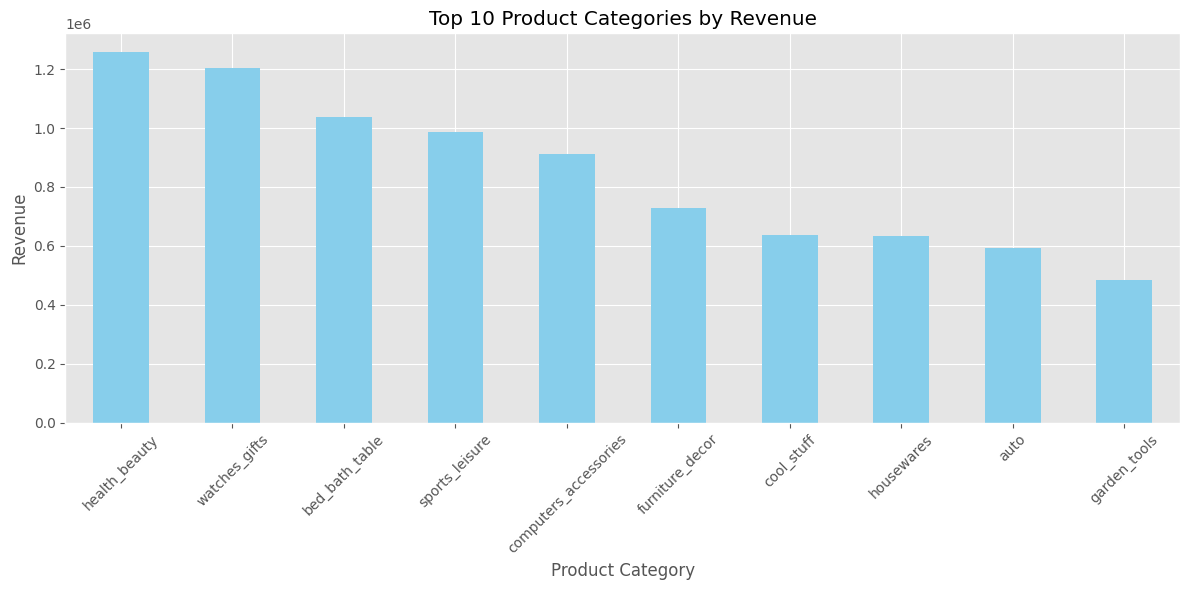

In [7]:
plt.figure(figsize=(12,6))

sales_per_category.plot(
    kind='bar',
    color='skyblue'
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Pertanyaan 2: Bagaimana tren jumlah order customer pada platform Olist selama periode tahun 2017-2018?

In [8]:
all_df['order_month'] = all_df[
    'order_purchase_timestamp'
].dt.to_period('M')

monthly_orders = all_df.groupby(
    'order_month'
)['order_id'].nunique()

monthly_orders

,order_id
order_month,
2016-09,3
2016-10,308
2016-12,1
2017-01,789
2017-02,1733
2017-03,2641
2017-04,2391
2017-05,3660
2017-06,3217


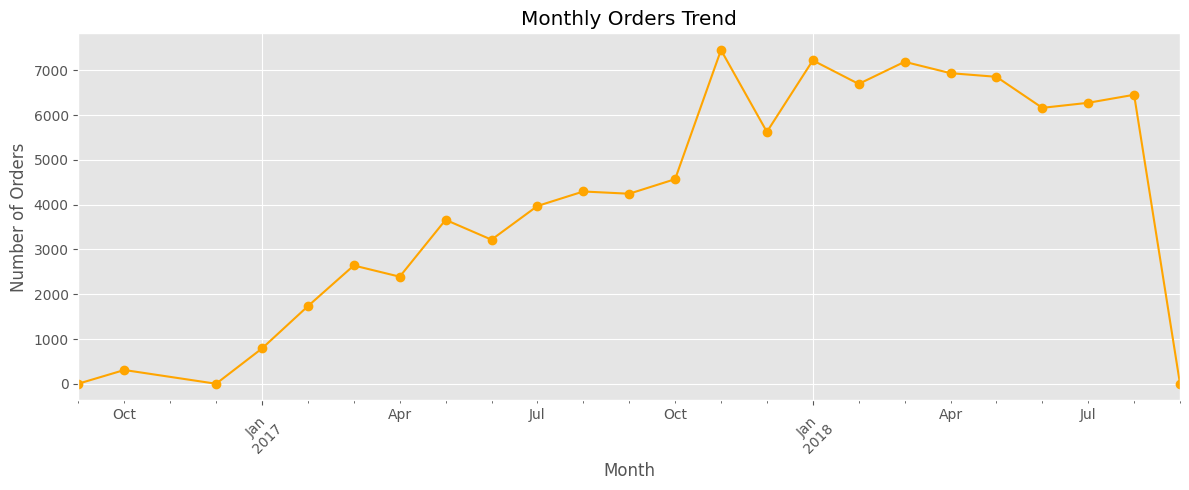

In [9]:
plt.figure(figsize=(12,5))

monthly_orders.plot(
    kind='line',
    marker='o',
    color='orange'
)

plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Insight:** (Opsional)
- Kategori produk dengan revenue tertinggi didominasi oleh kategori beauty, watches_gifts, dan bed_bath_table. Hal ini menunjukkan bahwa customer memiliki minat tinggi terhadap produk kecantikan, aksesoris, dan kebutuhan rumah tangga pada platform Olist.
- Jumlah order pada platform Olist mengalami fluktuasi dari waktu ke waktu. Pada beberapa periode terjadi peningkatan jumlah order yang menunjukkan adanya peningkatan aktivitas transaksi customer.

## Analisis Lanjutan (Opsional)

In [10]:
rfm_df = all_df.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})

rfm_df.columns = [
    "customer_id",
    "max_order_timestamp",
    "frequency",
    "monetary"
]

recent_date = all_df["order_purchase_timestamp"].max()

rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(
    lambda x: (recent_date - x).days
)

rfm_df.head()

,customer_id,max_order_timestamp,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,89.80,292
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,54.90,413
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,179.99,551
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,149.90,382
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,93.00,153


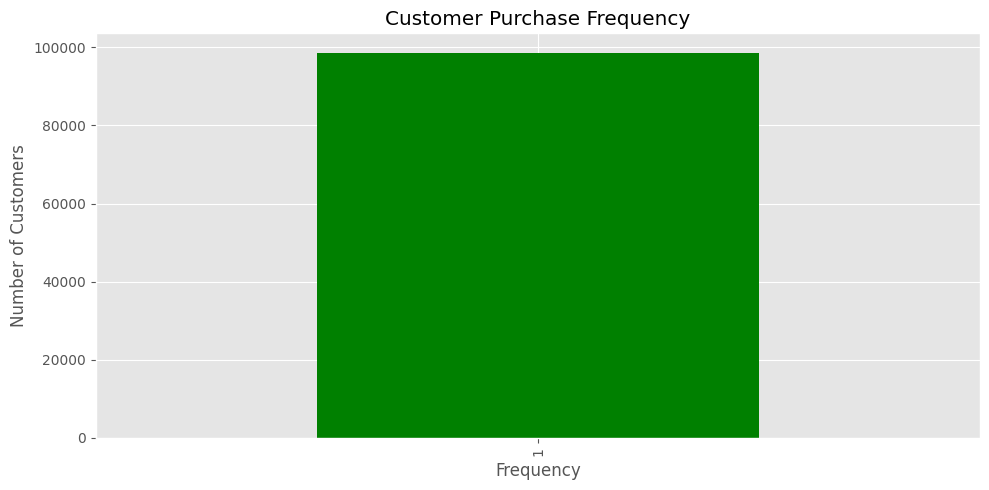

In [11]:
frequency_counts = rfm_df['frequency'].value_counts().sort_index()

plt.figure(figsize=(10,5))

frequency_counts.plot(
    kind='bar',
    color='green'
)

plt.title('Customer Purchase Frequency')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')

plt.tight_layout()

plt.show()

**Insight:** (Opsional)
- Sebagian besar customer hanya melakukan pembelian sebanyak satu kali. Hal ini menunjukkan bahwa tingkat customer retention pada platform masih relatif rendah dan perusahaan perlu meningkatkan strategi loyalitas pelanggan.


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori produk dengan revenue tertinggi berasal dari kategori beauty dan watches_gifts. Hal ini menunjukkan bahwa customer memiliki minat yang tinggi terhadap produk kecantikan dan aksesoris.
- **Conclusion pertanyaan 2:** Jumlah order pada platform Olist mengalami perubahan dari waktu ke waktu dengan beberapa periode menunjukkan peningkatan transaksi customer.


**Rekomendasi Action Item:**
- Fokus meningkatkan promosi pada kategori produk dengan revenue tertinggi seperti beauty dan watches_gifts.
- Memanfaatkan periode dengan peningkatan transaksi untuk membuat campaign promosi yang lebih efektif.
- Membuat program loyalitas customer untuk meningkatkan frequency pembelian.
- Melakukan evaluasi performa penjualan secara berkala berdasarkan tren order customer.

In [12]:
main_df = all_df[[
    'order_id',
    'order_purchase_timestamp',
    'price',
    'product_category_name_english'
]]

main_df.to_csv('main_data.csv', index=False)